# Exploratory Data Analysis

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 1. Importing data

In [87]:

csv_path = "../data/raw/store-data-6aa6d7a3f171f140353680.csv"

df = pd.read_csv(csv_path)


## 2. General overview

In [88]:
df.head()
df.tail()
df.columns.tolist()
df.info()
df.describe()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10064 entries, 0 to 10063
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10064 non-null  int64  
 1   Order ID       10064 non-null  object 
 2   Order Date     10064 non-null  object 
 3   Ship Date      9963 non-null   object 
 4   Ship Mode      9763 non-null   object 
 5   Customer ID    10064 non-null  object 
 6   Customer Name  9713 non-null   object 
 7   Segment        10064 non-null  object 
 8   Country        10064 non-null  object 
 9   City           10064 non-null  object 
 10  State          10064 non-null  object 
 11  Postal Code    9864 non-null   object 
 12  Region         10064 non-null  object 
 13  Product ID     10064 non-null  object 
 14  Category       10064 non-null  object 
 15  Sub-Category   10064 non-null  object 
 16  Product Name   10064 non-null  object 
 17  Sales          9863 non-null   float64
 18  Quanti

(10064, 21)

## 3. Missing values analysis

In [89]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().mean() * 100)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)
display(missing)


,missing_count,missing_percentage
Customer Name,351,3.487679
Ship Mode,301,2.990859
Sales,201,1.997218
Postal Code,200,1.987281
Quantity,199,1.977345
Ship Date,101,1.003577


## 4. Duplicate and id analysis

In [90]:

df['Row ID'].duplicated().sum()


np.int64(70)

In [105]:

duplicates = df[df.duplicated()]
display(duplicates)

clean_from_duplicates = df.drop_duplicates()


duplicates = clean_from_duplicates[clean_from_duplicates.duplicated()]
display(duplicates)

row_id_duplicates = clean_from_duplicates[clean_from_duplicates['Row ID'].duplicated(keep=False)].sort_values('Row ID')
display(row_id_duplicates)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9995,1442,CA-2017-128160,2017-12-19,2017-12-24,Second Class,MM-17920,NaN,Consumer,United States,San Francisco,...,94110.0,West,OFF-BI-10001510,Office Supplies,Binders,Deluxe Heavy-Duty Vinyl Round Ring Binder,NaN,2.0,0.2,11.4600
9996,4511,CA-2016-119935,2016-11-10,2016-11-14,Standard Class,KM-16225,NaN,Corporate,United States,Springfield,...,65807.0,Central,FUR-FU-10001085,Furniture,Furnishings,3M Polarizing Light Filter Sleeves,37.300,2.0,0.0,17.1580
9997,40,CA-2015-117415,2015-12-27,2015-12-31,Standard Class,SN-20710,NaN,Home Office,United States,Houston,...,77041.0,Central,FUR-CH-10004218,Furniture,Chairs,"Global Fabric Manager's Chair, Dark Gray",212.058,3.0,0.3,-15.1470
9998,4510,CA-2017-167003,2017-05-23,2017-05-29,Standard Class,VS-21820,NaN,Consumer,United States,Los Angeles,...,90036.0,West,FUR-TA-10001520,Furniture,Tables,"Lesro Sheffield Collection Coffee Table, End T...",171.288,3.0,0.2,-6.4233
10000,7364,CA-2016-127243,2016-11-28,2016-12-04,Standard Class,DS-13180,NaN,Corporate,United States,Philadelphia,...,19140.0,East,TEC-PH-10004539,Technology,Phones,Wireless Extenders zBoost YX545 SOHO Signal Bo...,340.182,3.0,0.4,-73.7061
10002,501,US-2016-105578,2016-05-30,2016-06-04,Standard Class,MY-17380,NaN,Corporate,United States,Parker,...,80134.0,West,OFF-BI-10001670,Office Supplies,Binders,Vinyl Sectional Post Binders,22.620,2.0,0.7,-15.0800
10003,4848,CA-2014-164469,2014-06-25,2014-06-27,Second Class,GK-14620,NaN,Corporate,United States,Salem,...,97301.0,West,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,71.632,11.0,0.2,17.9080
10004,4569,CA-2015-111990,2015-11-08,2015-11-13,Standard Class,DB-13660,NaN,Consumer,United States,Houston,...,77095.0,Central,OFF-BI-10003291,Office Supplies,Binders,Wilson Jones Leather-Like Binders with DublLoc...,10.476,6.0,0.8,-17.2854
10005,2759,CA-2016-146171,2016-03-11,2016-03-15,Standard Class,JP-16135,NaN,Home Office,United States,Columbus,...,31907.0,South,FUR-FU-10004270,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",76.920,4.0,0.0,31.5372
10006,6221,CA-2016-160220,2016-10-20,2016-10-26,Standard Class,JS-16030,NaN,Consumer,United States,Trenton,...,48183.0,Central,OFF-ST-10000617,Office Supplies,Storage,Woodgrain Magazine Files by Perma,20.860,7.0,0.0,1.4602


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
65,66,CA-2015-135545,2015-11-24,2015-11-30,Standard Class,KM-16720,Kunst Miller,Consumer,United States,Los Angeles,...,90004.0,West,FUR-FU-10000397,Furniture,Furnishings,Luxo Economy Swing Arm Lamp,79.760,4.0,0.0,22.3328
10045,66,CA-2015-135545,NaT,2015-11-30,Standard Class,KM-16720,KUNST MILLER,Consumer,United States,Los Angeles,...,90004.0,West,FUR-FU-10000397,Furniture,Furnishings,Luxo Economy Swing Arm Lamp,79.760,4.0,0.0,22.3328
10054,640,CA-2016-115917,2016-05-20,2016-05-25,Standard Class,RB-19465,RICK BENSLEY,Home Office,United States,Vallejo,...,94591.0,West,OFF-BI-10004728,Office Supplies,Binders,Wilson Jones Turn Tabs Binder Tool for Ring Bi...,15.424,4.0,0.2,5.0128
639,640,CA-2016-115917,2016-05-20,2016-05-25,Standard Class,RB-19465,Rick Bensley,Home Office,United States,Vallejo,...,94591.0,West,OFF-BI-10004728,Office Supplies,Binders,Wilson Jones Turn Tabs Binder Tool for Ring Bi...,15.424,4.0,0.2,5.0128
733,734,CA-2017-131954,2017-01-21,2017-01-25,Standard Class,DS-13030,NaN,Home Office,United States,Seattle,...,98115.0,West,TEC-AC-10003610,Technology,Accessories,Logitech Illuminated - Keyboard,NaN,3.0,0.0,86.3856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10056,9012,CA-2015-137071,2015-12-20,2015-12-21,First Class,ED-13885,EMILY DUCICH,Home Office,United States,Houston,...,77036.0,Central,TEC-AC-10004353,Technology,Accessories,Hypercom P1300 Pinpad,100.800,2.0,0.2,21.4200
10033,9240,CA-2017-110310,2017-10-27,2010-01-01,NaN,NB-18655,NaN,Corporate,United States,Tallahassee,...,32303.0,South,OFF-PA-10001685,Office Supplies,Paper,Easy-staple paper,56.784,7.0,0.2,20.5842
9239,9240,CA-2017-110310,2017-10-27,2017-11-02,NaN,NB-18655,NaN,Corporate,United States,Tallahassee,...,32303.0,South,OFF-PA-10001685,Office Supplies,Paper,Easy-staple paper,56.784,7.0,0.2,20.5842
10001,9952,CA-2017-121559,2017-06-01,2017-06-03,Second Class,HW-14935,NaN,Corporate,United States,Indianapolis,...,46203.0,Central,OFF-BI-10002072,Office Supplies,Binders,Cardinal Slant-D Ring Binders,17.380,2.0,0.0,8.6900


repeated Row ID values and exact duplicated rows should be removed

## 5. Descriptive statistics

In [92]:
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,10064.0,NaN,NaN,NaN,4994.397059,2885.84858,1.0,2496.75,4989.5,7494.25,9994.0
Order ID,10064,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10064,1495,9/5/2016,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9963,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9763,4,Standard Class,5822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10064,793,WB-21850,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9713,810,William Brown,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,10064,6,Consumer,5163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,10064,1,United States,10064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10064,634,New York City,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Date conversion and validation

In [93]:
for column in ['Order Date', 'Ship Date']:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors='coerce')

if {'Order Date', 'Ship Date'}.issubset(df.columns):
    invalid_dates = df[
        df['Order Date'].notna() &
        df['Ship Date'].notna() &
        (df['Ship Date'] < df['Order Date'])
    ]
    display(invalid_dates)


8

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1562,1563,US-2017-102890,2017-06-30,2010-01-01,Same Day,SG-20470,Sheri Gordon,Consumer,United States,New York City,...,10011.0,East,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.630,5.0,0.4,-295.9785
2517,2518,CA-2017-123134,2017-05-02,2010-01-01,Standard Class,DW-13585,Dorothy Wardle,Corporate,United States,Westfield,...,7090.0,East,FUR-FU-10003975,Furniture,Furnishings,Eldon Advantage Chair Mats for Low to Medium P...,129.930,3.0,0.0,12.9930
3279,3280,CA-2014-102988,2014-04-05,2010-01-01,Second Class,GM-14695,NaN,Corporate,United States,Alexandria,...,22304.0,South,OFF-AR-10000127,Office Supplies,Art,Newell 321,22.960,7.0,0.0,6.6584
4939,4940,CA-2014-157147,2014-01-13,2010-01-01,Standard Class,BD-11605,Brian Dahlen,Consumer,United States,San Francisco,...,94109.0,West,OFF-AR-10003514,Office Supplies,Art,4009 Highlighters by Sanford,19.900,5.0,0.0,6.5670
7099,7100,CA-2015-124933,2015-12-26,2010-01-01,Second Class,DF-13135,David Flashing,Consumer,United States,New York City,...,10009.0,East,OFF-PA-10003302,Office Supplies,Paper,Xerox 1906,212.640,6.0,0.0,99.9408
9101,9102,CA-2015-163181,2015-11-07,2010-01-01,NaN,AB-10105,Adrian Barton,Consumer,United States,Houston,...,77041.0,Central,OFF-AR-10001683,Office Supplies,Art,Lumber Crayons,23.640,3.0,0.2,5.3190
10010,6753,CA-2016-154767,2016-06-28,2010-01-01,Second Class,BP-11155,NaN,Consumer,United States,Paterson,...,7501.0,East,OFF-PA-10003039,Office Supplies,Paper,Xerox 1960,61.960,2.0,0.0,27.8820
10033,9240,CA-2017-110310,2017-10-27,2010-01-01,NaN,NB-18655,NaN,Corporate,United States,Tallahassee,...,32303.0,South,OFF-PA-10001685,Office Supplies,Paper,Easy-staple paper,56.784,7.0,0.2,20.5842


## 7. Numeric data-quality checks

In [102]:
# df[df['Quantity'] < 0]
if 'Quantity' in df.columns:
    negative_quantity = df[df['Quantity'] < 0]
    display(negative_quantity)

if 'Discount' in df.columns:
    invalid_discount = df[(df['Discount'] < 0) | (df['Discount'] > 1)]
    display(invalid_discount)


10

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
439,440,CA-2017-157252,2017-01-20,2017-01-23,Second Class,CV-12805,NaN,Corporate,United States,New York City,...,10024.0,East,FUR-CH-10003396,Furniture,Chairs,Global Deluxe Steno Chair,207.846,-5.0,0.1,2.3094
1481,1482,US-2016-108455,2016-12-02,2016-12-08,Standard Class,MK-18160,Mike Kennedy,Consumer,United States,San Francisco,...,94122.0,West,OFF-ST-10002214,Office Supplies,Storage,X-Rack File for Hanging Folders,33.870,-5.0,0.0,8.8062
2302,2303,CA-2016-106558,2016-01-17,2016-01-21,Standard Class,DL-13495,Dionis Lloyd,Corporate,United States,Columbus,...,31907.0,South,TEC-AC-10001142,Technology,Accessories,First Data FD10 PIN Pad,316.000,-5.0,0.0,31.6000
6511,6512,CA-2017-167640,2017-03-06,2017-03-10,Standard Class,FC-14245,Frank Carlisle,Home Office,United States,San Francisco,...,94109.0,West,OFF-AR-10003158,Office Supplies,Art,Fluorescent Highlighters by Dixon,23.880,-5.0,0.0,8.1192
7419,7420,US-2016-114013,2016-03-13,2016-03-15,Second Class,SC-20770,Stewart Carmichael,Corporate,United States,Philadelphia,...,19134.0,East,OFF-ST-10002574,Office Supplies,Storage,"SAFCO Commercial Wire Shelving, Black",552.560,-5.0,0.2,-138.1400
7894,7895,CA-2017-124744,2017-06-21,2017-06-25,Standard Class,EH-14125,Eugene Hildebrand,Home Office,United States,Wheeling,...,26003.0,East,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,82.400,-5.0,0.0,40.3760
8730,8731,CA-2015-103870,2015-12-27,2015-12-31,Standard Class,SP-20860,Sung Pak,Corporate,United States,Murfreesboro,...,37130.0,South,TEC-AC-10004227,Technology,Accessories,SanDisk Ultra 16 GB MicroSDHC Class 10 Memory ...,72.744,-5.0,0.2,-12.7302
9560,9561,CA-2016-129280,NaT,2016-05-05,First Class,SM-20905,Susan MacKendrick,Consumer,United States,Newark,...,43055.0,East,FUR-FU-10001876,Furniture,Furnishings,"Computer Room Manger, 14""",51.968,-5.0,0.2,10.3936
9662,9663,CA-2016-160717,2016-06-06,2016-06-11,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Santa Barbara,...,93101.0,West,TEC-PH-10001760,Technology,Phones,Bose SoundLink Bluetooth Speaker,477.600,-5.0,0.2,161.1900
9936,9937,CA-2017-132955,2017-06-24,2017-06-28,Standard Class,SC-20575,Sonia Cooley,Consumer,United States,Cranston,...,2920.0,East,OFF-BI-10002735,Office Supplies,Binders,GBC Prestige Therm-A-Bind Covers,102.930,-5.0,0.0,48.3771


10

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3096,3097,CA-2015-114468,2015-08-23,2015-08-23,Same Day,TD-20995,Tamara Dahlen,Consumer,United States,Bolingbrook,...,60440.0,Central,OFF-AP-10000696,Office Supplies,Appliances,Holmes Odor Grabber,5.768,2.0,1.5,-13.5548
3501,3502,CA-2016-108616,2016-09-29,2016-10-03,Standard Class,JK-15730,Joe Kamberova,Consumer,United States,Mobile,...,36608.0,South,OFF-AR-10001149,Office Supplies,Art,"Sanford Colorific Colored Pencils, 12/Box",25.920,9.0,1.5,7.7760
4551,4552,US-2014-165862,2014-07-13,2014-07-17,NaN,GK-14620,Grace Kelly,Corporate,United States,Los Angeles,...,90049.0,West,FUR-TA-10002855,Furniture,Tables,Bevis Round Conference Table Top & Single Colu...,351.216,3.0,1.5,4.3902
4710,4711,CA-2017-138149,2017-06-29,2017-06-30,First Class,WB-21850,William Brown,Consumer,United States,Los Angeles,...,90049.0,West,TEC-AC-10001284,Technology,Accessories,Enermax Briskie RF Wireless Keyboard and Mouse...,62.310,3.0,1.5,22.4316
6405,6406,CA-2017-154074,2017-08-31,2017-09-02,Second Class,BW-11110,Bart Watters,Corporate,United States,Spokane,...,99207.0,West,FUR-CH-10002331,Furniture,Chairs,Hon 4700 Series Mobuis Mid-Back Task Chairs wi...,569.568,2.0,1.5,7.1196
6457,6458,CA-2014-110065,2014-08-05,2014-08-11,Standard Class,SP-20650,Stephanie Phelps,Corporate,United States,New York City,...,10009.0,East,OFF-AR-10004165,Office Supplies,Art,Binney & Smith inkTank Erasable Pocket Highlig...,15.960,7.0,1.5,7.0224
6683,6684,CA-2014-109134,2014-11-05,2014-11-10,Standard Class,DE-13255,Deanra Eno,Home Office,United States,Los Angeles,...,90008.0,West,FUR-FU-10000320,Furniture,Furnishings,OIC Stacking Trays,20.040,6.0,1.5,8.8176
8814,8815,CA-2015-144274,2015-11-23,2015-11-25,Second Class,PW-19240,Pierre Wener,Consumer,United States,Wilmington,...,19805.0,East,TEC-PH-10003012,Technology,Phones,Nortel Meridian M3904 Professional Digital phone,307.980,2.0,1.5,89.3142
9291,9292,CA-2014-163650,2014-09-23,2014-09-25,First Class,TT-21220,Thomas Thornton,Consumer,United States,Dover,...,19901.0,East,OFF-BI-10004965,Office Supplies,Binders,Ibico Covers for Plastic or Wire Binding Elements,34.500,3.0,1.5,15.5250
9352,9353,CA-2017-148411,2017-09-24,2017-09-26,First Class,RO-19780,NaN,Consumer,United States,Chicago,...,60623.0,Central,FUR-CH-10003973,furniture,Chairs,GuestStacker Chair with Chrome Finish Legs,520.464,2.0,1.5,-14.8704


## 8. Univariate analysis

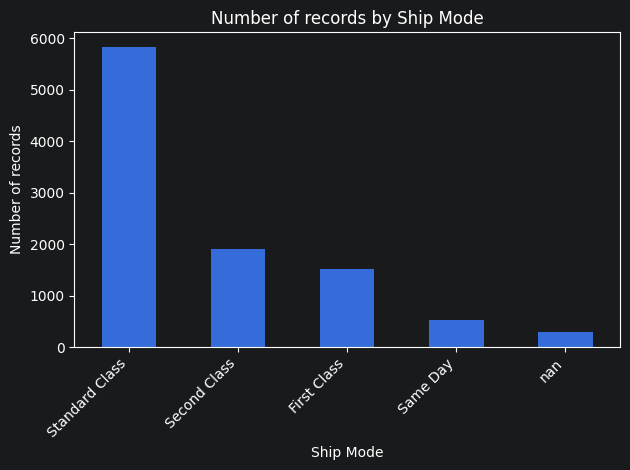

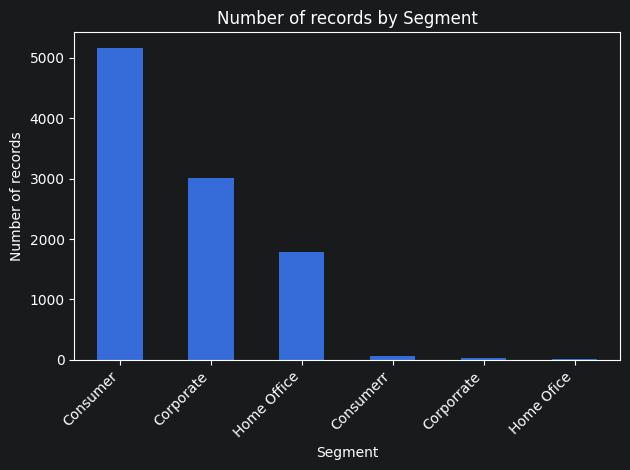

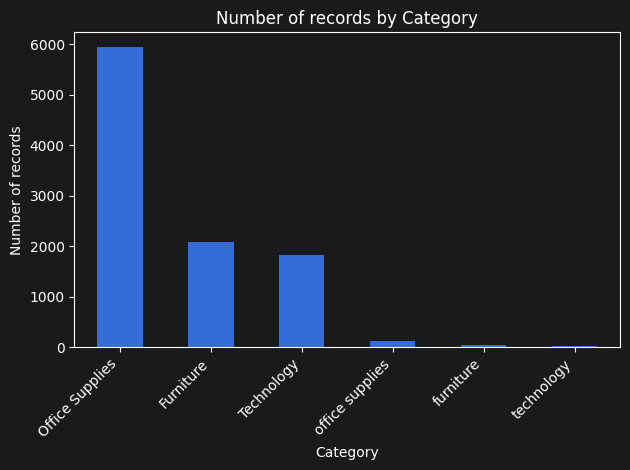

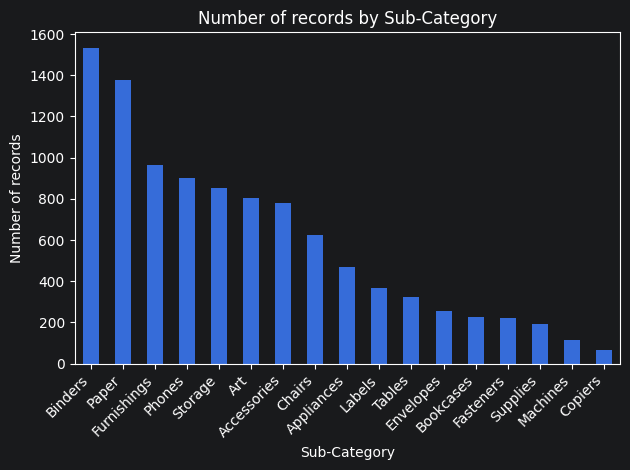

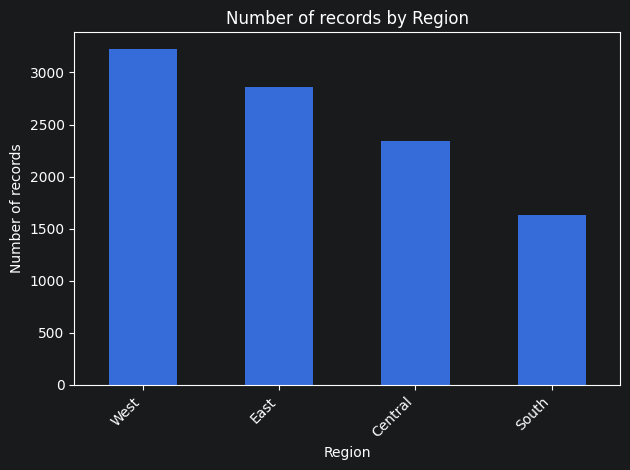

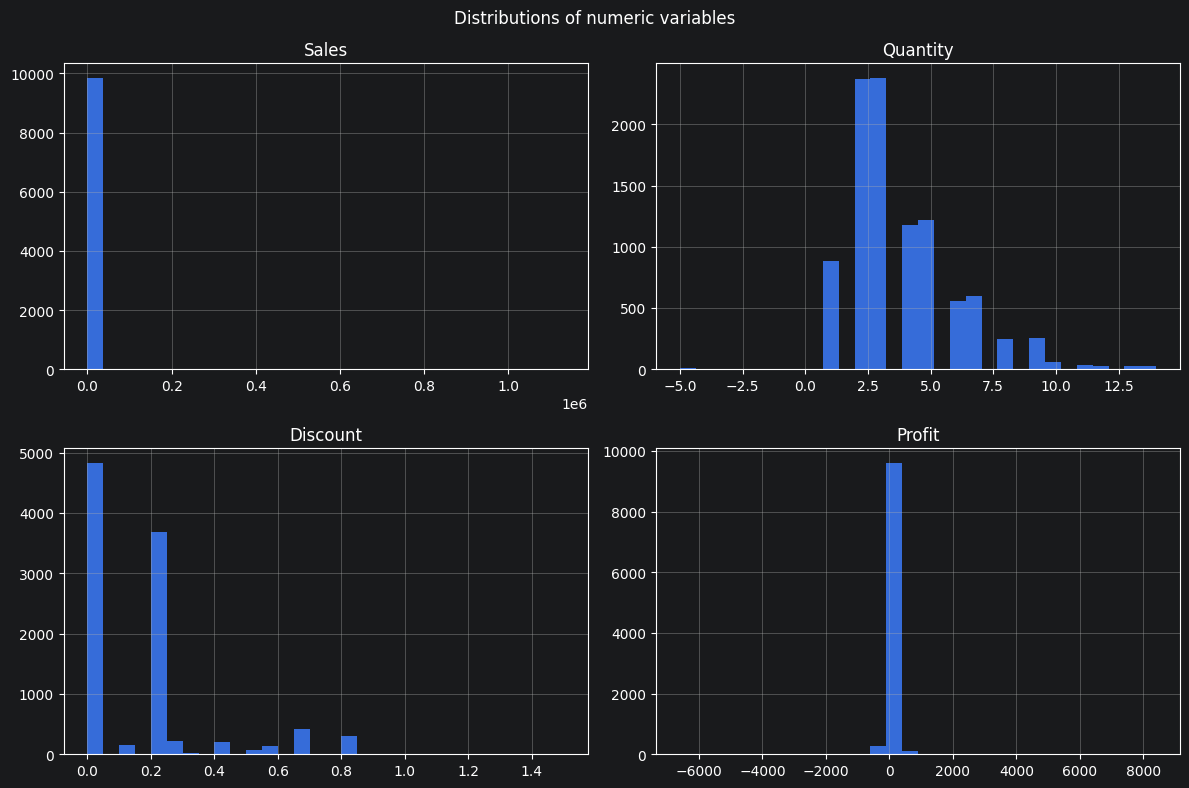

In [103]:
categorical_columns = [c for c in ['Ship Mode', 'Segment', 'Category', 'Sub-Category', 'Region'] if c in df.columns]
for column in categorical_columns:
    df[column].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Number of records by {column}')
    plt.xlabel(column)
    plt.ylabel('Number of records')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

numeric_columns = [c for c in ['Sales', 'Quantity', 'Discount', 'Profit'] if c in df.columns]
df[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.suptitle('Distributions of numeric variables')
plt.tight_layout()
plt.show()


## 9. Feature relationships and business analysis


,Sales,Profit
Category,,
Office Supplies,9.745228e+06,119693.6989
Furniture,6.374051e+06,18189.1929
Technology,3.067508e+06,143463.9587
office supplies,1.766765e+04,3331.9154
furniture,1.715474e+04,56.8583
technology,1.441781e+04,2806.0269


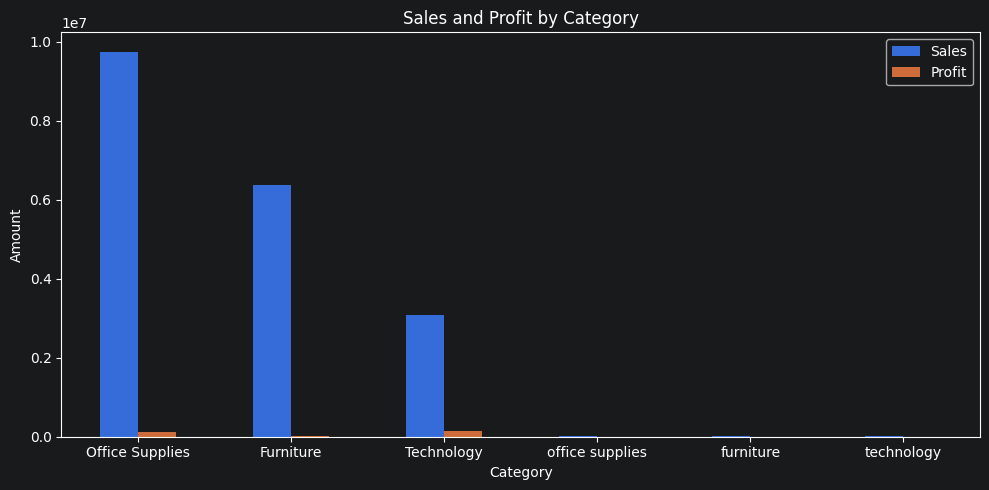

,Sales,Profit
Region,,
West,7.503194e+06,108718.9208
Central,7.275085e+06,40149.6446
East,2.935334e+06,91956.4231
South,1.522413e+06,46716.6626


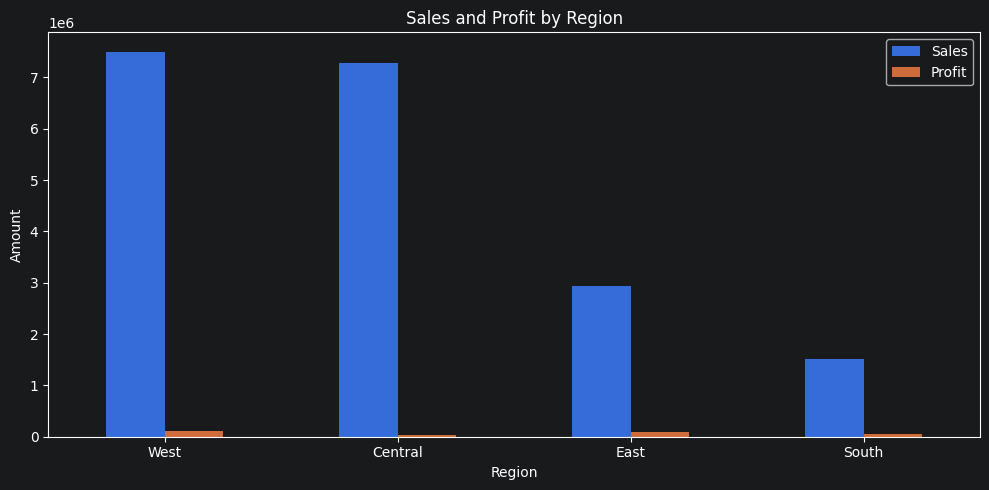

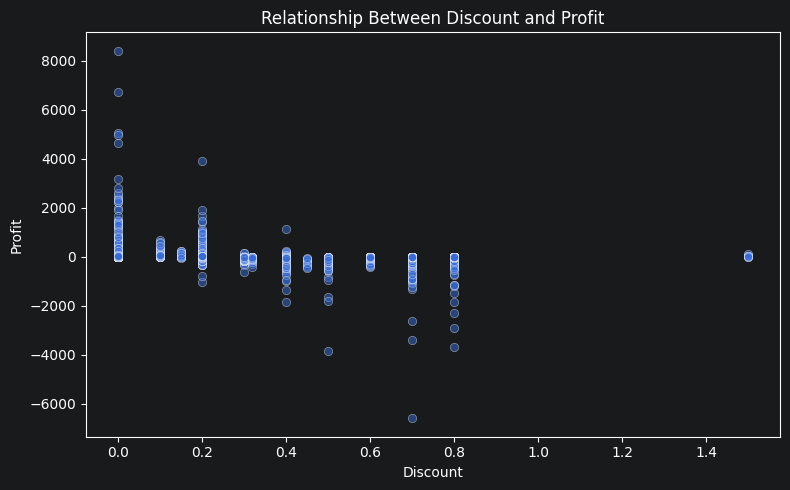

In [97]:
if {'Category', 'Sales', 'Profit'}.issubset(df.columns):
    category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    display(category_summary)
    category_summary.plot(kind='bar', figsize=(10, 5), title='Sales and Profit by Category')
    plt.ylabel('Amount')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

if {'Region', 'Sales', 'Profit'}.issubset(df.columns):
    region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    display(region_summary)
    region_summary.plot(kind='bar', figsize=(10, 5), title='Sales and Profit by Region')
    plt.ylabel('Amount')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

if {'Discount', 'Profit'}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
    plt.title('Relationship Between Discount and Profit')
    plt.tight_layout()
    plt.show()


segment level comparison, in the same style as the Category and Region breakdowns above


,Sales,Profit
Segment,,
Consumer,1.017622e+07,133519.5453
Corporate,5.216749e+06,91345.1198
Home Office,3.821814e+06,60455.9959
Consumerr,1.113247e+04,831.3729
Corporrate,6.710572e+03,917.0702
Home Ofice,3.401599e+03,472.5470


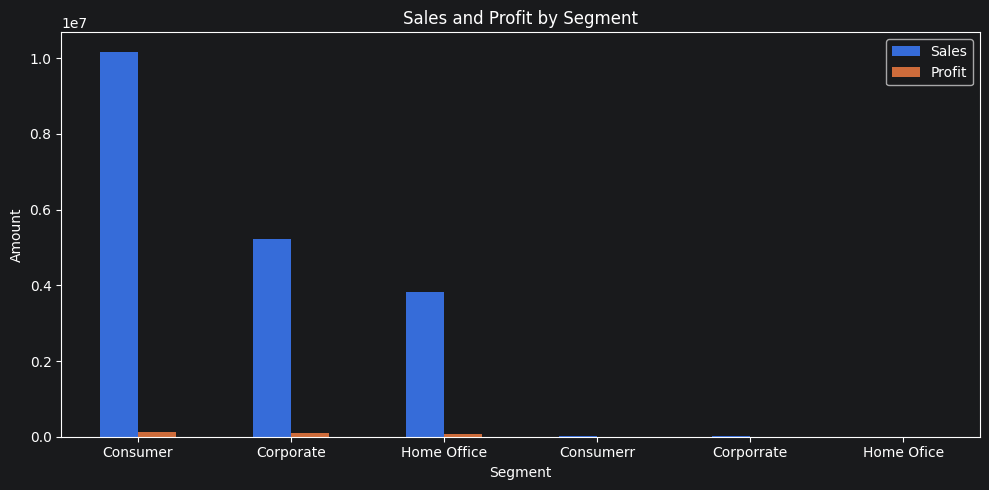

In [98]:
if {'Segment', 'Sales', 'Profit'}.issubset(df.columns):
    segment_summary = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
    display(segment_summary)
    segment_summary.plot(kind='bar', figsize=(10, 5), title='Sales and Profit by Segment')
    plt.ylabel('Amount')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


,Sales,Quantity,Discount,Profit
Sales,1.000000,-0.001902,0.004972,0.003309
Quantity,-0.001902,1.000000,0.014373,0.064227
Discount,0.004972,0.014373,1.000000,-0.215425
Profit,0.003309,0.064227,-0.215425,1.000000


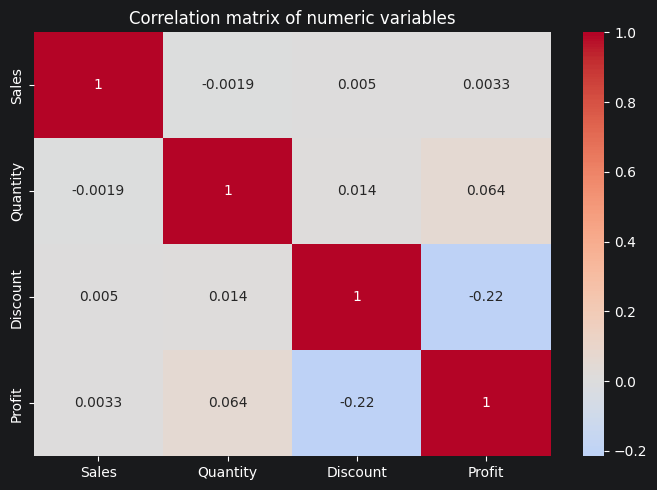

In [99]:
corr_matrix = df[numeric_columns].corr()
display(corr_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix of numeric variables')
plt.tight_layout()
plt.show()


## 10. Main findings for cleaning

1. deduplicate data: remove the duplicate rows and resolve the remaining Row ID conflicts
2. handle missing data: fill up or remove the missing values
3. Fix date errors: correct or drop records displaying reversed shipment dates.
4. Resolve numeric problem: fix the negative quantities and the invalid discount values.